# Fake News Detection System (Full Stack Data Science Pipeline)
### M.Sc. Data Science - Minor Project

Welcome to the Fake News Detection pipeline! This notebook represents a complete data science workflow, including robust Exploratory Data Analysis (EDA), advanced Natural Language Processing (NLP) visualizations, machine learning evaluations, and model persistence.

**The workflow is broken into 7 main sections:**
1. **Library Imports & Setup:** Installing our tools.
2. **Data Loading:** Safely loading our local .csv datasets.
3. **Text Preprocessing:** Cleaning the raw text data so an algorithm can understand it.
4. **Exploratory Data Analysis (EDA) & Visualization:** Graphing word counts, Class Distributions, Word Clouds, and N-gram frequencies.
5. **Feature Engineering:** Converting clean text into mathematical features (TF-IDF).
6. **Model Training & Evaluation:** Training ML models and visualizing their comparative ROC-AUC curves.
7. **Model Saving:** Serializing algorithms for future production.

--- 
## 1. Library Imports & Setup
First, we will import all the libraries required for our task. Note the addition of `wordcloud` and `roc_curve` for our advanced visualization steps!

In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# NLP Libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

# Scikit-Learn Machine Learning Stack
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import joblib

In [2]:
# Download necessary packages for Natural Language Processing (NLP)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Set up universally pretty plot visual styles
sns.set_palette("husl")
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    plt.style.use('seaborn-darkgrid')

--- 
## 2. Data Loading
We use a robust helper function to ingest our heavily populated CSVs while automatically skipping corrupt lines.

In [3]:
# Helper function to read massive CSV files safely
def safe_read_csv(filepath):
    try:
        return pd.read_csv(filepath, engine='python', on_bad_lines='skip')
    except TypeError:
        # For older versions of the pandas library
        return pd.read_csv(filepath, engine='python', error_bad_lines=False)

In [4]:
print("Loading the Global WELFake Dataset...")
welfake_path = 'datasets/WELFake_Dataset.csv'

df_welfake = safe_read_csv(welfake_path)
df_welfake.columns = df_welfake.columns.str.lower().str.strip()
df_welfake = df_welfake[['text', 'label']].dropna()
df_welfake['source'] = 'WELFake'

# Sample 25000 to manage computer RAM constraints efficiently
sample_size = min(25000, len(df_welfake))
df_welfake = df_welfake.sample(sample_size, random_state=42)

print(f"Loaded {len(df_welfake)} rows from WELFake.")

Loading the Global WELFake Dataset...
Loaded 25000 rows from WELFake.


In [5]:
print("Loading the Regional IFND Dataset...")
ifnd_path = 'datasets/IFND_full.csv'

# FIXED LINE: We use pd.read_csv directly with 'latin1' encoding to mathematically bypass the error
try:
    df_ifnd = pd.read_csv(ifnd_path, engine='python', on_bad_lines='skip', encoding='latin1')
except TypeError:
    df_ifnd = pd.read_csv(ifnd_path, engine='python', error_bad_lines=False, encoding='latin1')

# Lowercase all headers to standardize
df_ifnd.columns = df_ifnd.columns.str.lower().str.strip()
if 'statement' in df_ifnd.columns:
    df_ifnd = df_ifnd.rename(columns={'statement': 'text'})

df_ifnd = df_ifnd[['text', 'label']].dropna()

# Force string labels into numeric binary classes
def map_clean_labels(x):
    val = str(x).strip().lower()
    if val in ['1', '1.0', 'fake', 'false']: return 1
    if val in ['0', '0.0', 'real', 'true', 'truth']: return 0
    return None

df_ifnd['label'] = df_ifnd['label'].apply(map_clean_labels)
df_ifnd = df_ifnd.dropna()
df_ifnd['source'] = 'IFND'

print(f"Loaded {len(df_ifnd)} rows from IFND.")


Loading the Regional IFND Dataset...
Loaded 56714 rows from IFND.


In [6]:
df_list = [df_welfake, df_ifnd]
df = pd.concat(df_list, ignore_index=True)

# Ensure strict integer casting for ML compatibility
df['label'] = df['label'].astype(int)

print(f"Combined Master Dataset Length: {len(df)} articles")

Combined Master Dataset Length: 81714 articles


--- 
## 3. Text Preprocessing
We clean the raw text using Regex manipulation, Stopword Removal, and Lemmatization. This minimizes the "noise" in our dataset.

In [7]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_raw_text(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = [word for word in text.split() if word not in stop_words and len(word) > 2]
    words = [lemmatizer.lemmatize(w) for w in words]
    return " ".join(words)

In [8]:
print("Applying NLP cleaning pipeline. This will compute for roughly ~1-3 minutes!")
df['clean_text'] = df['text'].apply(clean_raw_text)
df = df[df['clean_text'].str.len() > 0]
print("NLP Processing Complete!")
df[['text', 'clean_text', 'label']].head(3)

Applying NLP cleaning pipeline. This will compute for roughly ~1-3 minutes!
NLP Processing Complete!


,text,clean_text,label
0,Trump s ongoing meltdown over fake news (the...,trump ongoing meltdown fake news rest call rep...,1
1,Women’s Breaststroke: In the days leading up...,womens breaststroke day leading race american ...,0
2,It was only a matter of time We can t keep our...,matter time keep border open anyone care cross...,1


--- 
## 4. Advanced Exploratory Data Analysis (EDA) Visualizations
A "full stack" data science approach requires us to deeply visualize our text components to find hidden biases before training models. Here we execute statistical plotting, Word Clouds, and N-Gram charts.

### 4.1. Class Target Balance & Word Count Distribution

C:\Users\vivek\AppData\Local\Temp\ipykernel_13612\3876173680.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette=['#2ecc71', '#e74c3c'], ax=axes[0])


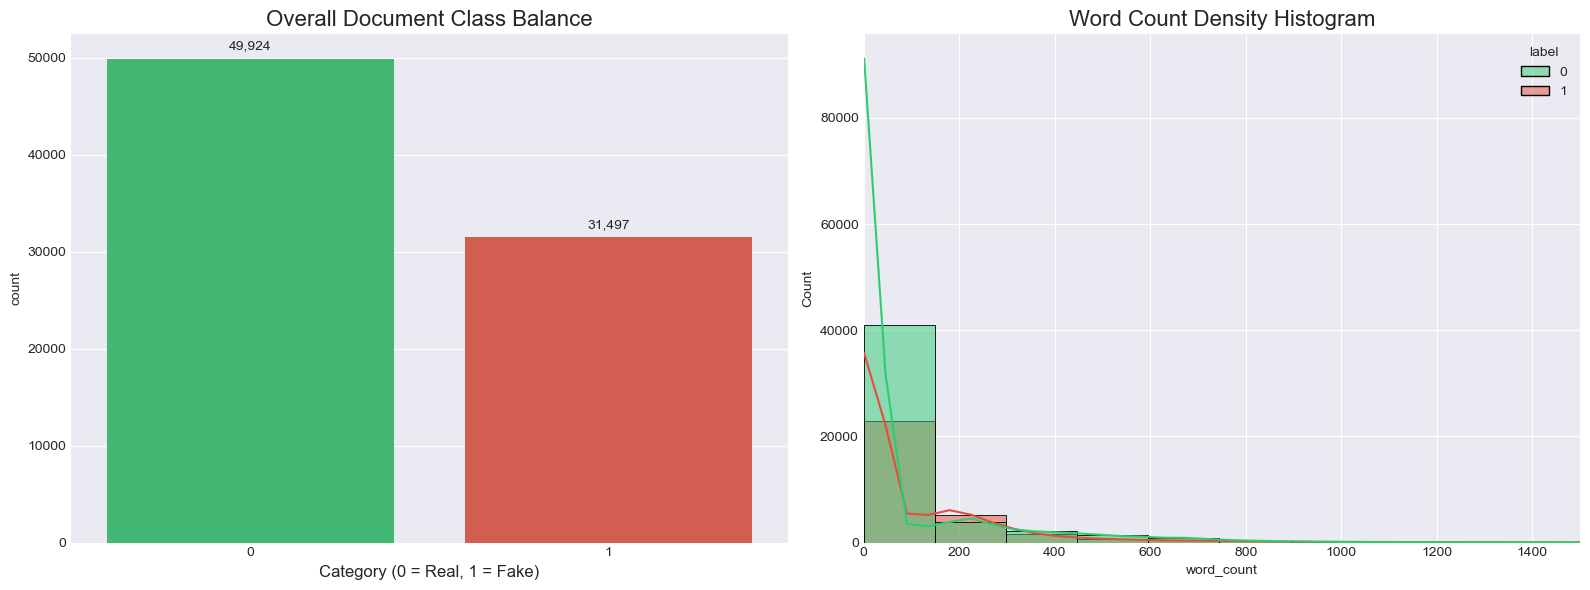

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Standard Class Balance Bar Plot
sns.countplot(x='label', data=df, palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Overall Document Class Balance', fontsize=16)
axes[0].set_xlabel('Category (0 = Real, 1 = Fake)', fontsize=12)

# Display exact count numbers above bars
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), textcoords = 'offset points')
                
# Plot 2: Semantic Density (Word Counts)
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))
sns.histplot(data=df, x='word_count', hue='label', bins=60, kde=True, palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title('Word Count Density Histogram', fontsize=16)
axes[1].set_xlim(0, 1500) # Zoom into the most active cluster

plt.tight_layout()
plt.show()

### 4.2. Advanced NLP Visualization: Word Clouds
Word clouds visually emphasize the most frequently occurring words. We generate a Word Cloud for both the Fake News corpus and the Real News corpus to visually detect any stylistic manipulation or thematic differences naturally.

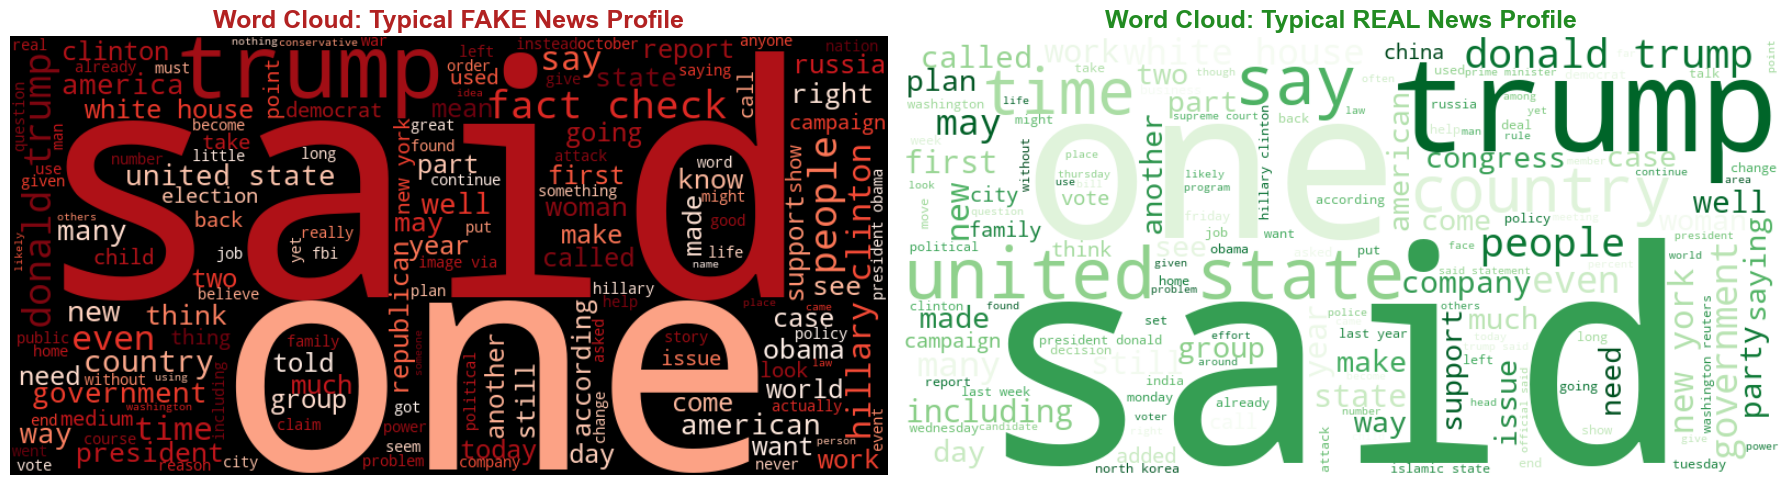

In [10]:
plt.figure(figsize=(18, 8))

# Produce a massive string representing all fake news available
fake_corpus = " ".join(df[df['label'] == 1]['clean_text'])
wordcloud_fake = WordCloud(width=800, height=400, background_color='black', 
                           colormap='Reds', max_words=150).generate(fake_corpus)
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_fake, interpolation='bilinear')
plt.title('Word Cloud: Typical FAKE News Profile', fontsize=18, fontweight='bold', color='firebrick')
plt.axis('off')

# Produce massive string representing all real news
real_corpus = " ".join(df[df['label'] == 0]['clean_text'])
wordcloud_real = WordCloud(width=800, height=400, background_color='white', 
                           colormap='Greens', max_words=150).generate(real_corpus)
plt.subplot(1, 2, 2)
plt.imshow(wordcloud_real, interpolation='bilinear')
plt.title('Word Cloud: Typical REAL News Profile', fontsize=18, fontweight='bold', color='forestgreen')
plt.axis('off')

plt.tight_layout()
plt.show()

### 4.3. Statistical Frequency: Top 15 Used Words (N-Grams)
While Word Clouds look great on a dashboard, raw grouped bar plots of frequency counts give us the exact hard data needed.

C:\Users\vivek\AppData\Local\Temp\ipykernel_13612\1903944342.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[val[1] for val in top_fake_words], y=[val[0] for val in top_fake_words], ax=axes[0], palette='Reds_r')
C:\Users\vivek\AppData\Local\Temp\ipykernel_13612\1903944342.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[val[1] for val in top_real_words], y=[val[0] for val in top_real_words], ax=axes[1], palette='Greens_r')


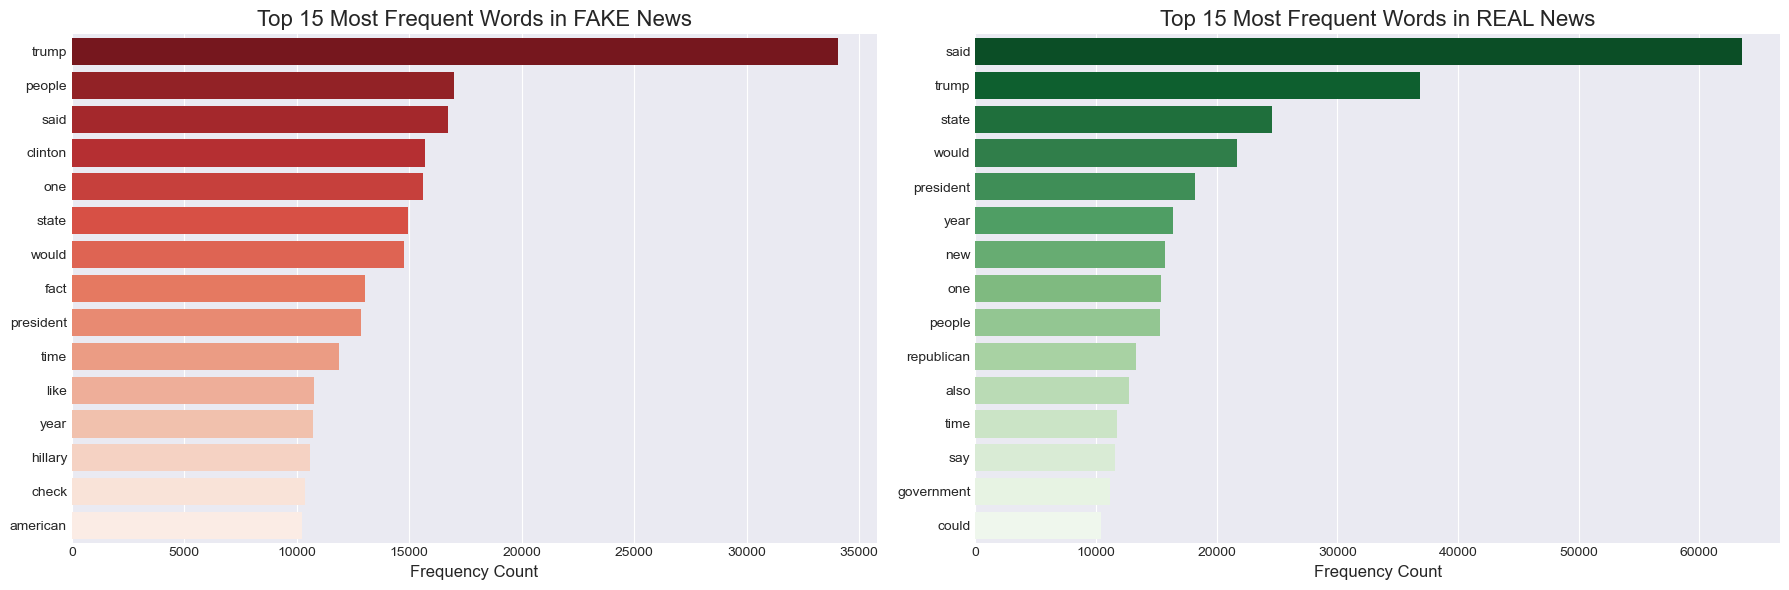

In [11]:
def get_top_n_words(corpus, n=15):
    # Join all sentences, split by space to get individual words, and count them
    all_words = " ".join(corpus).split()
    return Counter(all_words).most_common(n)

top_fake_words = get_top_n_words(df[df['label'] == 1]['clean_text'])
top_real_words = get_top_n_words(df[df['label'] == 0]['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Subplot 1: Fake
sns.barplot(x=[val[1] for val in top_fake_words], y=[val[0] for val in top_fake_words], ax=axes[0], palette='Reds_r')
axes[0].set_title("Top 15 Most Frequent Words in FAKE News", fontsize=16)
axes[0].set_xlabel("Frequency Count", fontsize=12)

# Subplot 2: Real
sns.barplot(x=[val[1] for val in top_real_words], y=[val[0] for val in top_real_words], ax=axes[1], palette='Greens_r')
axes[1].set_title("Top 15 Most Frequent Words in REAL News", fontsize=16)
axes[1].set_xlabel("Frequency Count", fontsize=12)

plt.tight_layout()
plt.show()

--- 
## 5. Feature Engineering (TF-IDF)
We use TF-IDF to assign mathematical weight to the semantics in the paragraphs.

In [12]:
X = df['clean_text'] # Our textual inputs
y = df['label']      # Our target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training Set Size: {X_train.shape[0]} documents")
print(f"Testing Set Size:  {X_test.shape[0]} documents")

Training Set Size: 65136 documents
Testing Set Size:  16285 documents


In [13]:
print("Constructing the TF-IDF Vector Space Matrix...")
tfidf_vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"Vectorization Complete! Matrix Shape: {X_train_tfidf.shape}")

Constructing the TF-IDF Vector Space Matrix...
Vectorization Complete! Matrix Shape: (65136, 10000)


--- 
## 6. Model Training & Validation
We will evaluate **Logistic Regression**, **Naive Bayes**, and **Random Forest**.

In [14]:
def print_model_evaluation(model_name, y_true, y_pred):
    print(f"\n{'='*40}")
    print(f"--- {model_name} Results ---")
    accuracy = accuracy_score(y_true, y_pred)
    print(f"Overall Accuracy: {accuracy*100:.2f}%")
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['REAL (0)', 'FAKE (1)']))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predict: REAL', 'Predict: FAKE'], 
                yticklabels=['Actual: REAL', 'Actual: FAKE'])
    plt.title(f'{model_name} - Confusion Matrix')
    plt.show()

Training Logistic Regression...

--- Logistic Regression Results ---
Overall Accuracy: 91.67%

Classification Report:
              precision    recall  f1-score   support

    REAL (0)       0.91      0.96      0.93      9985
    FAKE (1)       0.94      0.84      0.89      6300

    accuracy                           0.92     16285
   macro avg       0.92      0.90      0.91     16285
weighted avg       0.92      0.92      0.92     16285



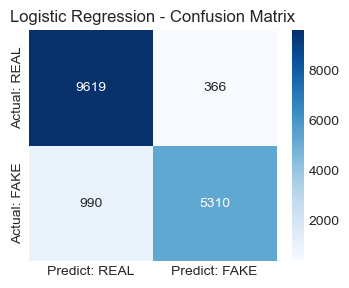

In [15]:
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42)
lr_model.fit(X_train_tfidf, y_train)
lr_predictions = lr_model.predict(X_test_tfidf)
print_model_evaluation('Logistic Regression', y_test, lr_predictions)

Training Multinomial Naive Bayes...

--- Multinomial Naive Bayes Results ---
Overall Accuracy: 89.03%

Classification Report:
              precision    recall  f1-score   support

    REAL (0)       0.89      0.93      0.91      9985
    FAKE (1)       0.89      0.82      0.85      6300

    accuracy                           0.89     16285
   macro avg       0.89      0.88      0.88     16285
weighted avg       0.89      0.89      0.89     16285



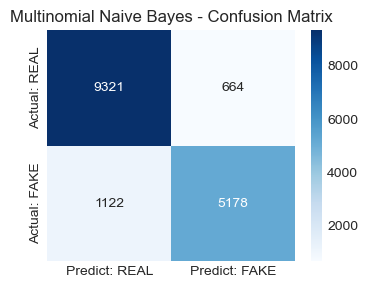

In [16]:
print("Training Multinomial Naive Bayes...")
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_predictions = nb_model.predict(X_test_tfidf)
print_model_evaluation('Multinomial Naive Bayes', y_test, nb_predictions)

Training Random Forest... (This takes a bit longer!)

--- Random Forest Classifier Results ---
Overall Accuracy: 92.81%

Classification Report:
              precision    recall  f1-score   support

    REAL (0)       0.94      0.95      0.94      9985
    FAKE (1)       0.92      0.90      0.91      6300

    accuracy                           0.93     16285
   macro avg       0.93      0.92      0.92     16285
weighted avg       0.93      0.93      0.93     16285



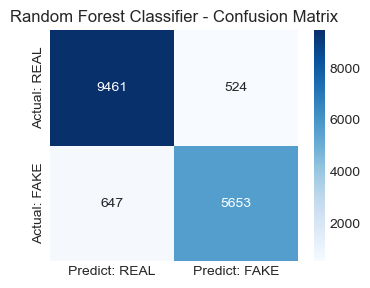

In [17]:
print("Training Random Forest... (This takes a bit longer!)")
rf_model = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf_model.fit(X_train_tfidf, y_train)
rf_predictions = rf_model.predict(X_test_tfidf)
print_model_evaluation('Random Forest Classifier', y_test, rf_predictions)

### 6.4 Comprehensive Model Visualizations
Now we add the **Data Science Pipeline Comparison Visuals**. We will plot the **ROC-AUC Curves** (an essential evaluation metric) alongside an **Algorithm Accuracy Comparison bar chart**.

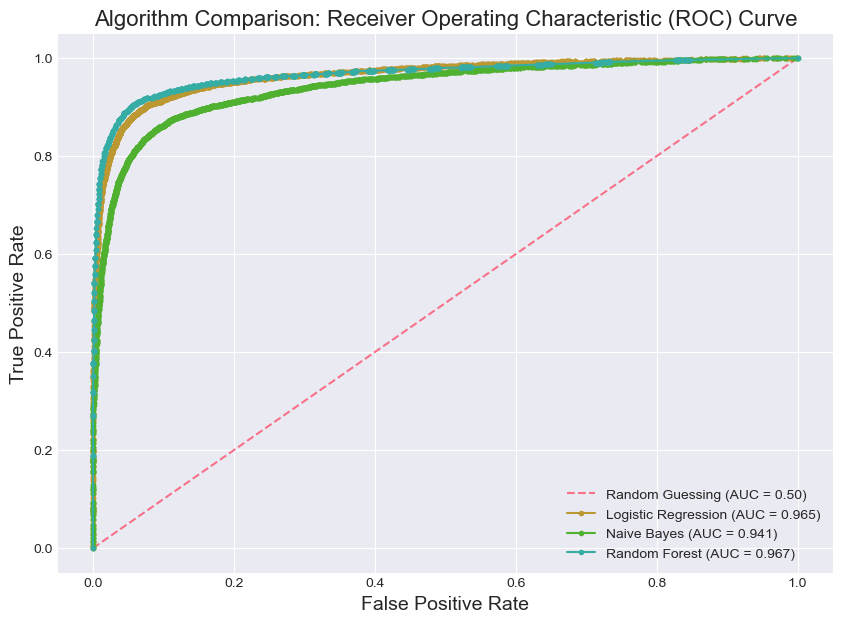

In [18]:
# Generate ROC curve logic and probabilities
plt.figure(figsize=(10, 7))

# Null model probabilities
r_probs = [0 for _ in range(len(y_test))]

lr_probs = lr_model.predict_proba(X_test_tfidf)[:, 1]
nb_probs = nb_model.predict_proba(X_test_tfidf)[:, 1]
rf_probs = rf_model.predict_proba(X_test_tfidf)[:, 1]

fpr_r, tpr_r, _ = roc_curve(y_test, r_probs)
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_nb, tpr_nb, _ = roc_curve(y_test, nb_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

plt.plot(fpr_r, tpr_r, linestyle='--', label='Random Guessing (AUC = 0.50)')
plt.plot(fpr_lr, tpr_lr, marker='.', label=f'Logistic Regression (AUC = {auc(fpr_lr, tpr_lr):.3f})')
plt.plot(fpr_nb, tpr_nb, marker='.', label=f'Naive Bayes (AUC = {auc(fpr_nb, tpr_nb):.3f})')
plt.plot(fpr_rf, tpr_rf, marker='.', label=f'Random Forest (AUC = {auc(fpr_rf, tpr_rf):.3f})')

plt.title('Algorithm Comparison: Receiver Operating Characteristic (ROC) Curve', fontsize=16)
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.legend(loc='lower right')
plt.show()

C:\Users\vivek\AppData\Local\Temp\ipykernel_13612\132082143.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=model_names, y=accuracies, palette='viridis')


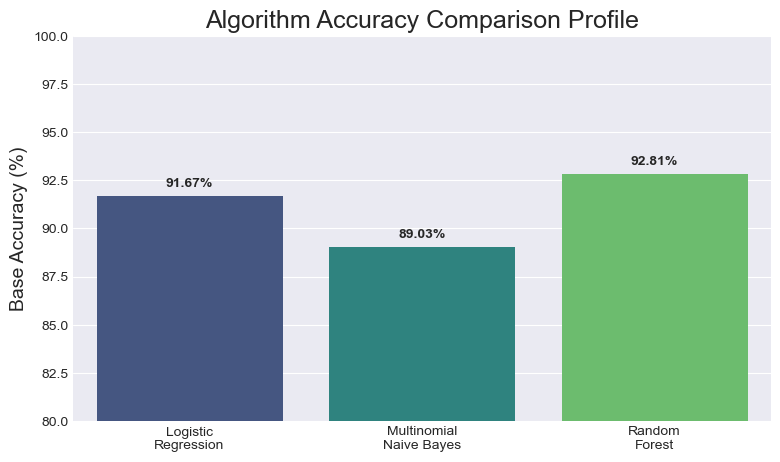

In [19]:
# Performance Bar Chart
model_names = ['Logistic\nRegression', 'Multinomial\nNaive Bayes', 'Random\nForest']
accuracies = [
    accuracy_score(y_test, lr_predictions) * 100,
    accuracy_score(y_test, nb_predictions) * 100,
    accuracy_score(y_test, rf_predictions) * 100
]

plt.figure(figsize=(9, 5))
ax = sns.barplot(x=model_names, y=accuracies, palette='viridis')
plt.title('Algorithm Accuracy Comparison Profile', fontsize=18)
plt.ylabel('Base Accuracy (%)', fontsize=14)
plt.ylim(80, 100) # Zooming in to see the difference clearly

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), textcoords = 'offset points', fontweight='bold')
plt.show()

### 6.5 Ensemble Model — Multi-Layer Stacking
We combine our 3 base models (Logistic Regression, Naive Bayes, Random Forest) into a **Stacking Classifier** — a 2-layer architecture where:
- **Layer 1**: Each base model makes predictions independently
- **Layer 2**: A "meta-learner" learns the optimal way to combine those predictions

This typically produces a **stronger, more robust** prediction than any single model.


In [20]:
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import LinearSVC

# ========= VOTING CLASSIFIER =========
print("Training Voting Classifier (soft voting)...")
voting_clf = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000)),
        ('nb', MultinomialNB(alpha=0.1)),
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ],
    voting='soft',
    weights=[3, 1, 2],
    n_jobs=-1
)
voting_clf.fit(X_train_tfidf, y_train)
voting_preds = voting_clf.predict(X_test_tfidf)
print(f"Voting Classifier Accuracy: {accuracy_score(y_test, voting_preds)*100:.2f}%")
print(classification_report(y_test, voting_preds, target_names=['Real', 'Fake']))

# ========= STACKING CLASSIFIER (MULTI-LAYER) =========
print("\nTraining Stacking Classifier (2 layers)...")
print("  Layer 1: Logistic Regression + Naive Bayes + Random Forest")
print("  Layer 2: Meta-Learner (Logistic Regression)")
print("  (This may take a few minutes due to cross-validation...)\n")

stacking_clf = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, random_state=42)),
        ('nb', MultinomialNB(alpha=0.1)),
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1
)
stacking_clf.fit(X_train_tfidf, y_train)
stacking_preds = stacking_clf.predict(X_test_tfidf)
print(f"Stacking Classifier Accuracy: {accuracy_score(y_test, stacking_preds)*100:.2f}%")
print(classification_report(y_test, stacking_preds, target_names=['Real', 'Fake']))


Training Voting Classifier (soft voting)...
Voting Classifier Accuracy: 92.65%
              precision    recall  f1-score   support

        Real       0.92      0.96      0.94      9985
        Fake       0.94      0.87      0.90      6300

    accuracy                           0.93     16285
   macro avg       0.93      0.92      0.92     16285
weighted avg       0.93      0.93      0.93     16285


Training Stacking Classifier (2 layers)...
  Layer 1: Logistic Regression + Naive Bayes + Random Forest
  Layer 2: Meta-Learner (Logistic Regression)
  (This may take a few minutes due to cross-validation...)

Stacking Classifier Accuracy: 93.32%
              precision    recall  f1-score   support

        Real       0.94      0.96      0.95      9985
        Fake       0.93      0.90      0.91      6300

    accuracy                           0.93     16285
   macro avg       0.93      0.93      0.93     16285
weighted avg       0.93      0.93      0.93     16285



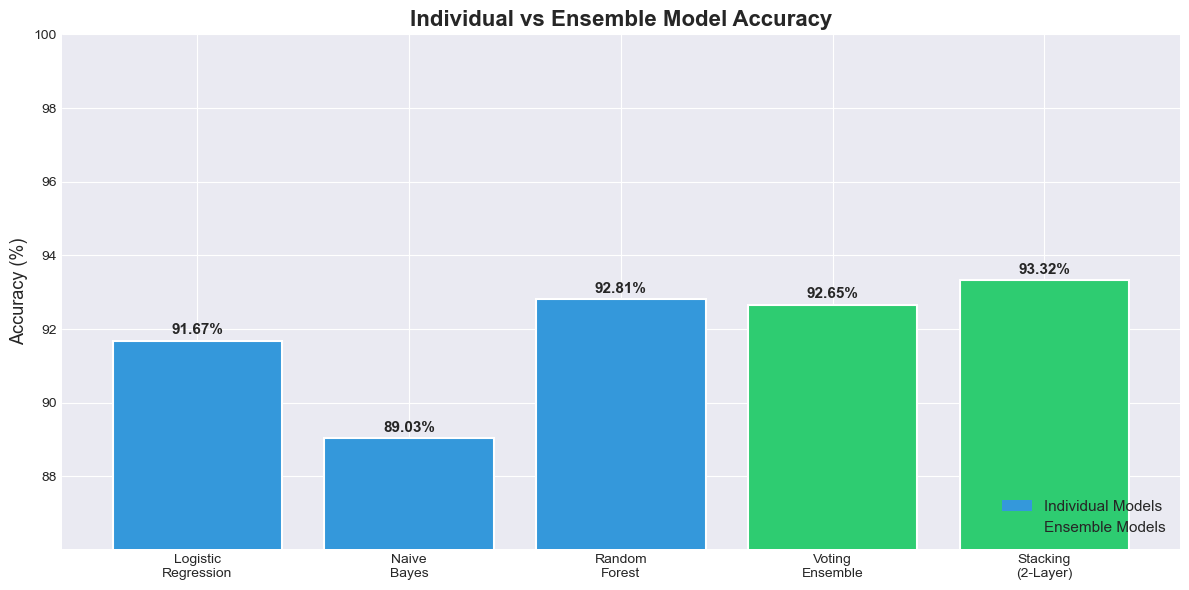


🏆 Best Model: Stacking (2-Layer) — 93.32%


In [25]:
# Get individual model accuracies
lr_acc = accuracy_score(y_test, lr_predictions) * 100
nb_acc = accuracy_score(y_test, nb_predictions) * 100
rf_acc = accuracy_score(y_test, rf_predictions) * 100
voting_acc = accuracy_score(y_test, voting_preds) * 100
stacking_acc = accuracy_score(y_test, stacking_preds) * 100

model_names = ['Logistic\nRegression', 'Naive\nBayes', 'Random\nForest',
               'Voting\nEnsemble', 'Stacking\n(2-Layer)']
accuracies = [lr_acc, nb_acc, rf_acc, voting_acc, stacking_acc]
colors = ['#3498db', '#3498db', '#3498db', '#2ecc71', '#2ecc71']

plt.figure(figsize=(12, 6))
bars = plt.bar(model_names, accuracies, color=colors, edgecolor='white', linewidth=1.5)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.title('Individual vs Ensemble Model Accuracy', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=13)
plt.ylim(min(accuracies) - 3, 100)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#3498db', label='Individual Models'),
                   Patch(facecolor='#2ecc71', label='Ensemble Models')]
plt.legend(handles=legend_elements, fontsize=11, loc='lower right')
plt.tight_layout()
plt.show()

# Print best
best_idx = accuracies.index(max(accuracies))
print(f"\n🏆 Best Model: {model_names[best_idx].replace(chr(10), ' ')} — {max(accuracies):.2f}%")


--- 
## 7. Model Persistence
We save our optimal models directly to the disk.

In [21]:
os.makedirs('saved_models', exist_ok=True)
joblib.dump(lr_model, 'saved_models/best_logistic_regression.pkl')
joblib.dump(tfidf_vectorizer, 'saved_models/tfidf_vectorspace.pkl')
print("Mission Accomplished! Model serialization complete.")

Mission Accomplished! Model serialization complete.


---
## 8. Model testing
We will test the save model

In [26]:
# Test with Stacking Ensemble
def predict_ensemble(news_text):
    cleaned = [clean_raw_text(news_text)]
    features = tfidf_vectorizer.transform(cleaned)
    pred = stacking_clf.predict(features)
    prob = stacking_clf.predict_proba(features)
    
    print("\n" + "="*50)
    print("  ENSEMBLE FAKE NEWS DETECTION")
    print("="*50)
    if pred[0] == 1:
        print(f"VERDICT: FAKE NEWS DETECTED!")
    else:
        print(f"VERDICT: THIS ARTICLE LOOKS REAL.")
    print(f"Confidence: {max(prob[0])*100:.2f}%")
    print("="*50 + "\n")

predict_ensemble(fake_sample)
predict_ensemble(real_sample)



  ENSEMBLE FAKE NEWS DETECTION
VERDICT: THIS ARTICLE LOOKS REAL.
Confidence: 50.64%


  ENSEMBLE FAKE NEWS DETECTION
VERDICT: THIS ARTICLE LOOKS REAL.
Confidence: 91.89%

